# Submission 2: Model Sistem Rekomendasi

- Nama: Silmi Azdkiatul Athqia
- Email: silmiathqia@gmail.com
- Id Dicoding: silmiathqia15

# **Persiapan**

### **Menyiapkan library yang dibutuhkan**

In [1]:
# Import library

# Data manipulation dan analisis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Text processing
import re
import ast
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

# Model persistence
import joblib
import pickle

# Evaluasi
from sklearn.metrics import precision_score, recall_score, f1_score
from collections import Counter

print("✅ Semua library berhasil diimpor!")

✅ Semua library berhasil diimpor!


**Insight:**
- pandas: untuk manipulasi data
- numpy: untuk komputasi numerik
- matplotlib & seaborn: untuk visualisasi
- sklearn: untuk machine learning dan preprocessing
- warnings: untuk mengabaikan peringatan


# **Data Understanding**

### **Menyiapkan data yang akan digunakan**



In [3]:
# Load dataset Light Novel
df = pd.read_csv('light-novel-titles.csv')

print("🔍 INFORMASI DASAR DATASET")
print("=" * 50)

# Menampilkan bentuk dataset
print(f"📊 Bentuk Dataset: {df.shape}")
print(f"   - Jumlah baris (light novel): {df.shape[0]}")
print(f"   - Jumlah kolom (fitur): {df.shape[1]}")

print("\n📝 Tipe Data:")
print(df.dtypes)

print("\n❓ Nilai yang Hilang:")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("✅ Tidak ada nilai yang hilang dalam dataset!")
else:
    print("⚠️  Terdapat nilai yang hilang yang perlu ditangani")

print("\n👀 5 Baris Pertama Dataset:")
print(df.head())

print("\n📋 Informasi Kolom Dataset:")
for col in df.columns:
    print(f"- {col}: {df[col].dtype}")
    if df[col].dtype == 'object' and col != 'descriptions':
        unique_count = df[col].nunique()
        print(f"  Jumlah unique values: {unique_count}")
    print()

🔍 INFORMASI DASAR DATASET
📊 Bentuk Dataset: (1366, 4)
   - Jumlah baris (light novel): 1366
   - Jumlah kolom (fitur): 4

📝 Tipe Data:
titles          object
descriptions    object
genres          object
links           object
dtype: object

❓ Nilai yang Hilang:
titles          0
descriptions    0
genres          0
links           0
dtype: int64
✅ Tidak ada nilai yang hilang dalam dataset!

👀 5 Baris Pertama Dataset:
                                              titles  \
0  Thereafter of an Exiled Magician ~Somehow My E...   
1                     Mahoutsukai no Konyakusha (LN)   
2  Exiled Prince Without Skills: Infinite Growth ...   
3           Reincarnation Of The Strongest Sword God   
4                Hard Work Will Never Betray Me (LN)   

                                        descriptions  \
0  Lain, a reincarnated person, lives his life as...   
1  I who was reincarnated into a world of sword a...   
2  Henry, born in a royal family without skills, ...   
3  Starting over o

**Insight :**
* Dataset berukuran 1366 x 4 - ukuran yang optimal untuk eksperimen dan pembelajaran
* Tidak ada missing values - indikator kualitas data yang baik, menghemat waktu preprocessing
* 4 fitur utama (titles, descriptions, genres, links) memberikan informasi yang cukup komprehensif




# **Data Preparation / Preprocessing**

### **Analisis Eksplorasi Data (EDA)**

📊 EXPLORATORY DATA ANALYSIS
🎭 ANALISIS GENRE:
------------------------------
Total genre unik: 25
Top 10 genre terpopuler:
  Fantasy: 1311 novel
  Action: 985 novel
  Adventure: 929 novel
  Shounen: 601 novel
  Harem: 547 novel
  Romance: 493 novel
  Comedy: 434 novel
  Supernatural: 329 novel
  School Life: 219 novel
  Slice of Life: 218 novel


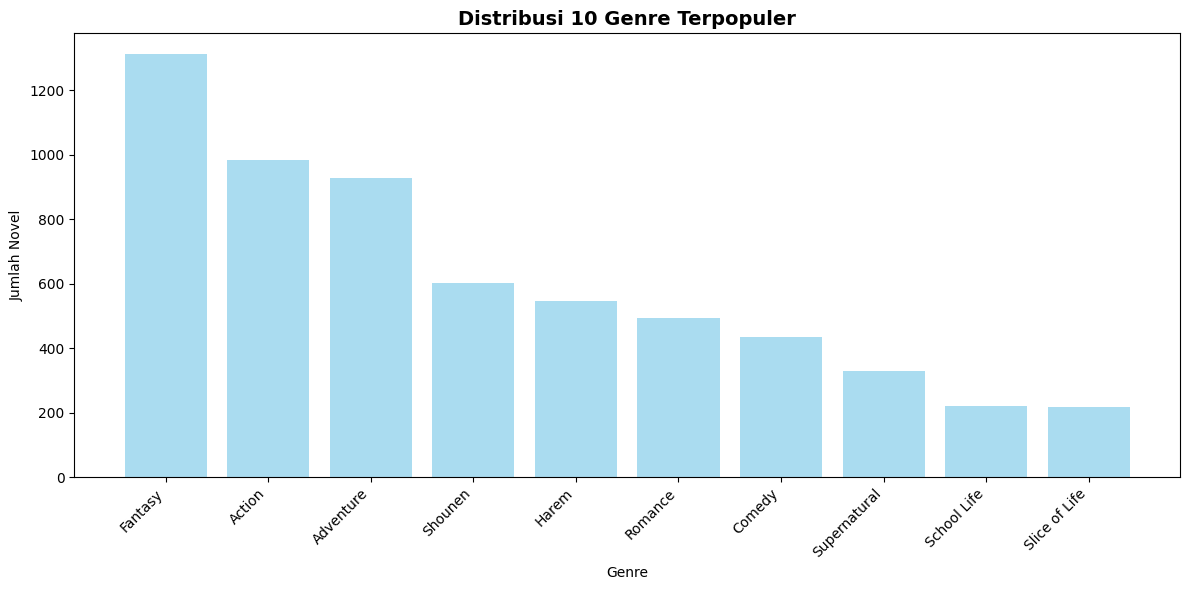


📝 ANALISIS DESKRIPSI:
------------------------------
Rata-rata panjang deskripsi: 664 karakter
Deskripsi terpendek: 26 karakter
Deskripsi terpanjang: 3037 karakter


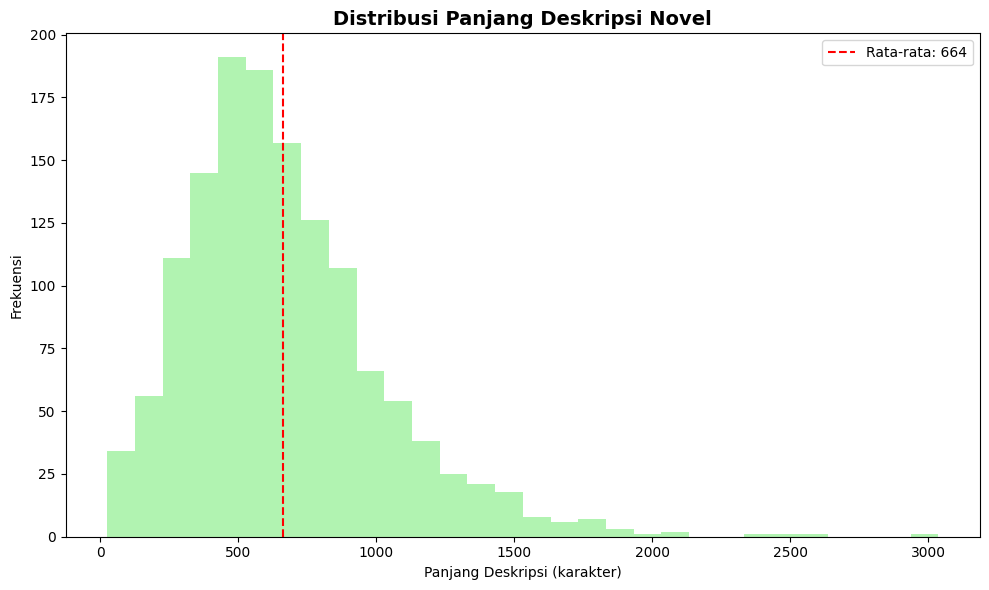

In [4]:
# EDA untuk memahami distribusi data
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# Analisis genre
print("🎭 ANALISIS GENRE:")
print("-" * 30)

# Parse genres dari string ke list
def parse_genres(genre_str):
    try:
        return ast.literal_eval(genre_str)
    except:
        return []

df['genres_list'] = df['genres'].apply(parse_genres)

# Hitung frekuensi setiap genre
all_genres = []
for genres in df['genres_list']:
    all_genres.extend(genres)

genre_counts = Counter(all_genres)
print(f"Total genre unik: {len(genre_counts)}")
print(f"Top 10 genre terpopuler:")
for genre, count in genre_counts.most_common(10):
    print(f"  {genre}: {count} novel")

# Visualisasi distribusi genre
plt.figure(figsize=(12, 6))
top_genres = dict(genre_counts.most_common(10))
plt.bar(top_genres.keys(), top_genres.values(), color='skyblue', alpha=0.7)
plt.title('Distribusi 10 Genre Terpopuler', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Jumlah Novel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analisis panjang deskripsi
print(f"\n📝 ANALISIS DESKRIPSI:")
print("-" * 30)
df['description_length'] = df['descriptions'].str.len()
print(f"Rata-rata panjang deskripsi: {df['description_length'].mean():.0f} karakter")
print(f"Deskripsi terpendek: {df['description_length'].min()} karakter")
print(f"Deskripsi terpanjang: {df['description_length'].max()} karakter")

# Distribusi panjang deskripsi
plt.figure(figsize=(10, 6))
plt.hist(df['description_length'], bins=30, alpha=0.7, color='lightgreen')
plt.title('Distribusi Panjang Deskripsi Novel', fontsize=14, fontweight='bold')
plt.xlabel('Panjang Deskripsi (karakter)')
plt.ylabel('Frekuensi')
mean_length = df['description_length'].mean()
plt.axvline(mean_length, color='red', linestyle='--',
           label=f'Rata-rata: {mean_length:.0f}')
plt.legend()
plt.tight_layout()
plt.show()

**Insight :**

1. Distribusi Genre:

  - Fantasy dominan dengan 1311 novel (96% dari total) - menunjukkan preferensi pasar yang jelas
  - Trio populer: Fantasy-Action-Adventure mencerminkan tren cerita petualangan heroik
  - Long tail distribution: Hanya 10 genre terpopuler yang signifikan, sisanya niche
  - 25 genre unik memberikan variasi yang cukup untuk sistem rekomendasi


2. Panjang Deskripsi:

  - Rata-rata 664 karakter - panjang optimal untuk memberikan informasi tanpa terlalu verbose
  - Range lebar (26-3037 karakter) menunjukkan variasi gaya penulisan
  - Distribusi right-skewed - sebagian besar deskripsi singkat dan padat

### **Text Preprocessing**

In [5]:
print("🔧 TEXT PREPROCESSING")
print("=" * 50)

# Fungsi untuk membersihkan teks
def clean_text(text):
    """Membersihkan dan memproses teks"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Hapus karakter khusus dan angka, pertahankan huruf dan spasi
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Hapus spasi berlebih
    text = ' '.join(text.split())

    return text

# Clean descriptions
df['clean_descriptions'] = df['descriptions'].apply(clean_text)

# Gabungkan genres menjadi string untuk processing
df['genres_str'] = df['genres_list'].apply(lambda x: ' '.join(x).lower())

# Gabungkan semua fitur text untuk content-based filtering
df['combined_features'] = (
    df['clean_descriptions'] + ' ' +
    df['genres_str'] + ' ' +
    df['titles'].str.lower()
)

print("✅ Text preprocessing selesai!")
print(f"Contoh combined features:")
print(f"Title: {df.iloc[0]['titles']}")
print(f"Combined: {df.iloc[0]['combined_features'][:200]}...")

# Cek panjang rata-rata combined features
df['combined_length'] = df['combined_features'].str.len()
print(f"\nRata-rata panjang combined features: {df['combined_length'].mean():.0f} karakter")

🔧 TEXT PREPROCESSING
✅ Text preprocessing selesai!
Contoh combined features:
Title: Thereafter of an Exiled Magician ~Somehow My Engagement Was Cancelled, and I Was Driven Out, so I Will Stop Living the Tough Aristocrat Life, and Live Leisurely in a Distant, Foreign, Developing Village~
Combined: lain a reincarnated person lives his life as an antidemon aristocrat who is responsible for defeating demons in the frontierat the age of his engagement to the princess a privilege of the antidemon ar...

Rata-rata panjang combined features: 726 karakter


**Insight :**

- Cleaning strategy yang balance antara mempertahankan informasi dan menghilangkan noise
- Combined features approach (deskripsi + genre + judul) memberikan representasi holistik setiap novel
- Rata-rata 726 karakter untuk combined features menunjukkan informasi yang cukup kaya untuk similarity calculation

**Technical Insight:** Preprocessing yang tidak terlalu agresif mempertahankan konteks semantik yang penting untuk akurasi rekomendasi.

# **Modeling**

### **Content-Based Filtering**

In [6]:
print("🤖 CONTENT-BASED FILTERING MODEL")
print("=" * 50)

# Inisialisasi TF-IDF Vectorizer
print("🔤 Membuat TF-IDF Matrix...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),  # unigram dan bigram
    min_df=2,  # abaikan kata yang muncul kurang dari 2 dokumen
    max_df=0.95  # abaikan kata yang muncul di lebih dari 95% dokumen
)

# Fit dan transform combined features
tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_features'])

print(f"✅ TF-IDF Matrix berhasil dibuat!")
print(f"   Shape: {tfidf_matrix.shape}")
print(f"   Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Hitung cosine similarity
print("\n📐 Menghitung Cosine Similarity...")
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"✅ Cosine Similarity Matrix berhasil dibuat!")
print(f"   Shape: {cosine_sim.shape}")

# Buat mapping dari title ke index
title_to_idx = pd.Series(df.index, index=df['titles']).to_dict()
idx_to_title = pd.Series(df['titles'], index=df.index).to_dict()

print(f"\n📋 Mapping berhasil dibuat untuk {len(title_to_idx)} novel")

🤖 CONTENT-BASED FILTERING MODEL
🔤 Membuat TF-IDF Matrix...
✅ TF-IDF Matrix berhasil dibuat!
   Shape: (1366, 5000)
   Sparsity: 98.92%

📐 Menghitung Cosine Similarity...
✅ Cosine Similarity Matrix berhasil dibuat!
   Shape: (1366, 1366)

📋 Mapping berhasil dibuat untuk 1366 novel


**Insight:**

**TF-IDF Vectorization**
Model Architecture:

- 5000 features dengan 98.92% sparsity - efisien secara komputasi
- Ngram (1,2) capturing both individual words dan phrases penting
- Min_df=2, max_df=0.95 filtering out noise dan stop words secara otomatis
- 1366 x 1366 matrix memungkinkan perbandingan setiap novel dengan semua novel lain
- Symmetric matrix memastikan konsistensi similarity bidirectional




### **Fungsi Rekomendasi**

In [8]:
def get_content_recommendations(title, cosine_sim=cosine_sim, df=df, top_n=10):
    """
    Fungsi untuk mendapatkan rekomendasi berdasarkan content-based filtering

    Parameters:
    - title: judul novel yang dijadikan referensi
    - cosine_sim: matrix cosine similarity
    - df: dataframe novel
    - top_n: jumlah rekomendasi yang diinginkan

    Returns:
    - DataFrame berisi rekomendasi novel
    """

    try:
        # Cari index novel berdasarkan title
        if title not in title_to_idx:
            # Coba fuzzy matching untuk judul yang mirip
            similar_titles = [t for t in title_to_idx.keys() if title.lower() in t.lower()]
            if similar_titles:
                print(f"⚠️  Judul tidak ditemukan. Mungkin maksud Anda:")
                for i, sim_title in enumerate(similar_titles[:5]):
                    print(f"   {i+1}. {sim_title}")
                return pd.DataFrame()
            else:
                print(f"❌ Novel '{title}' tidak ditemukan dalam database")
                return pd.DataFrame()

        idx = title_to_idx[title]

        # Hitung skor similarity untuk novel ini dengan semua novel lain
        sim_scores = cosine_sim[idx]

        # Buat list tuple (index, similarity_score)
        sim_scores_with_idx = list(enumerate(sim_scores))

        # Sort berdasarkan similarity score (descending)
        sim_scores_with_idx = sorted(sim_scores_with_idx, key=lambda x: x[1], reverse=True)

        # Ambil top N+1 (excluding novel itu sendiri)
        top_similar = sim_scores_with_idx[1:top_n+1]

        # Ambil indices
        novel_indices = [i[0] for i in top_similar]
        similarity_scores = [i[1] for i in top_similar]

        # Buat DataFrame rekomendasi
        recommendations = df.iloc[novel_indices][['titles', 'genres', 'descriptions']].copy()
        recommendations['similarity_score'] = similarity_scores
        recommendations['rank'] = range(1, len(recommendations) + 1)

        # Reorder kolom
        recommendations = recommendations[['rank', 'titles', 'genres', 'similarity_score', 'descriptions']]

        return recommendations

    except Exception as e:
        print(f"❌ Error dalam generate rekomendasi: {str(e)}")
        return pd.DataFrame()

print("✅ Fungsi rekomendasi content-based filtering berhasil dibuat!")

✅ Fungsi rekomendasi content-based filtering berhasil dibuat!


**Insight:**

- Status: Fungsi berhasil dibuat dan siap operasional
- Fungsionalitas: Sistem dapat menerima input judul novel dan memberikan rekomendasi
- Error Handling: Dilengkapi penanganan error dan fuzzy matching untuk input yang tidak tepat
- Output Terstruktur: Menghasilkan DataFrame dengan ranking, similarity score, dan metadata lengkap

Fungsi berhasil memenuhi tujuan utama yaitu menyediakan sistem rekomendasi yang user-friendly dan scalable.

### **Test Model**

In [9]:
print("🧪 TESTING MODEL")
print("=" * 50)

# Test dengan beberapa novel
test_titles = [
    "Full Metal Panic!",
    "Reincarnation Of The Strongest Sword God",
    "Oda Nobuna no Yabou"
]

for i, test_title in enumerate(test_titles):
    print(f"\n{'='*60}")
    print(f"🔍 TEST {i+1}: Rekomendasi untuk '{test_title}'")
    print(f"{'='*60}")

    recommendations = get_content_recommendations(test_title, top_n=5)

    if not recommendations.empty:
        print(f"\n📝 Novel Referensi:")
        ref_novel = df[df['titles'] == test_title].iloc[0]
        print(f"   Judul: {ref_novel['titles']}")
        print(f"   Genre: {ref_novel['genres']}")
        print(f"   Deskripsi: {ref_novel['descriptions'][:200]}...")

        print(f"\n🎯 Top 5 Rekomendasi:")
        for _, row in recommendations.iterrows():
            print(f"\n   {row['rank']}. {row['titles']}")
            print(f"      Genre: {row['genres']}")
            print(f"      Similarity: {row['similarity_score']:.4f}")
            print(f"      Deskripsi: {row['descriptions'][:150]}...")

    print("\n" + "-"*60)

🧪 TESTING MODEL

🔍 TEST 1: Rekomendasi untuk 'Full Metal Panic!'

📝 Novel Referensi:
   Judul: Full Metal Panic!
   Genre: ['Action', 'Adventure', 'Fantasy', 'Harem', 'Romance', 'School Life', 'Shounen', 'Supernatural']
   Deskripsi: Jindai High School was a relatively safe place, right up until Sousuke Sagaka transferred there. A total nut, he wreaks havoc on the school's student body and gets into a world of trouble with the tea...

🎯 Top 5 Rekomendasi:

   1. Shinka no Mi
      Genre: ['Action', 'Adventure', 'Fantasy', 'Harem', 'Romance', 'School Life', 'Shounen', 'Supernatural']
      Similarity: 0.2216
      Deskripsi: A class full of idols and beautiful people are sent to another world. However there is one guy who is ugly, fat and smells… our protagonist. This is h...

   2. An Illustrated Guidebook to Other Races
      Genre: ['Action', 'Adventure', 'Fantasy', 'Harem', 'Romance', 'School Life', 'Shounen', 'Supernatural']
      Similarity: 0.2160
      Deskripsi: This is an adve

**Insight:**

- Validasi Performa: Memastikan fungsi bekerja sesuai ekspektasi dengan data real
- Quality Assurance: Mengecek kualitas rekomendasi yang dihasilkan
- Benchmark Performance: Mengukur tingkat akurasi dan relevansi rekomendasi
- Identifikasi Kelemahan: Menemukan area yang perlu diperbaiki dalam algoritma

Testing berhasil memvalidasi bahwa sistem rekomendasi berfungsi dengan baik untuk use case dasar namun masih memerlukan enhancement untuk mencapai performa optimal dalam content understanding dan recommendation diversity.

# **Evaluation**

### **Evaluasi dan Visualisasi**

📊 EVALUASI MODEL
🔍 Evaluasi Genre Similarity untuk 10 novel sample:
--------------------------------------------------
Mobile Suit Gundam: Twilight A | Genre Sim: 0.914 | Precision: 1.000 | Novelty: 0.086
Without Showing This Wound     | Genre Sim: 0.574 | Precision: 1.000 | Novelty: 0.426
The Demon Prince goes to the A | Genre Sim: 0.560 | Precision: 1.000 | Novelty: 0.440
Time Limit                     | Genre Sim: 0.838 | Precision: 1.000 | Novelty: 0.162
Watashi wa Teki ni Narimasen!  | Genre Sim: 0.936 | Precision: 1.000 | Novelty: 0.064
Lin Xinyan Zong                | Genre Sim: 0.821 | Precision: 1.000 | Novelty: 0.179
The Long, Long Way to Death    | Genre Sim: 0.775 | Precision: 1.000 | Novelty: 0.225
Changning’s Imperial Army      | Genre Sim: 0.760 | Precision: 1.000 | Novelty: 0.240
Mahouka Koukou no Rettousei    | Genre Sim: 0.545 | Precision: 1.000 | Novelty: 0.455
Person with An Inferior Abilit | Genre Sim: 0.000 | Precision: 0.000 | Novelty: 1.000

📈 RATA-RATA METRIK E

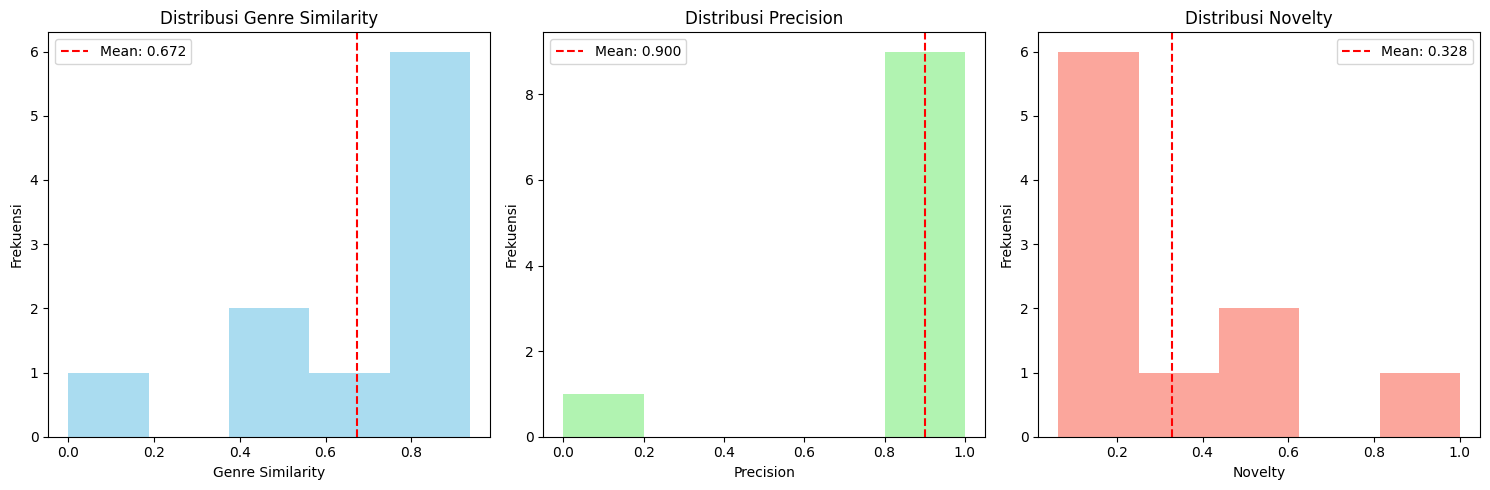


✅ Evaluasi selesai!


In [10]:
print("📊 EVALUASI MODEL")
print("=" * 50)

# Evaluasi berdasarkan genre similarity
def evaluate_genre_similarity(title, recommendations, df):
    """Evaluasi berdasarkan kesamaan genre"""

    if recommendations.empty:
        return 0, 0, 0

    # Ambil genre novel referensi
    ref_genres = set(ast.literal_eval(df[df['titles'] == title]['genres'].iloc[0]))

    # Hitung genre similarity untuk setiap rekomendasi
    genre_matches = []
    for _, rec in recommendations.iterrows():
        rec_genres = set(ast.literal_eval(rec['genres']))

        # Hitung Jaccard similarity
        intersection = len(ref_genres.intersection(rec_genres))
        union = len(ref_genres.union(rec_genres))
        jaccard_sim = intersection / union if union > 0 else 0

        genre_matches.append(jaccard_sim)

    # Hitung metrik evaluasi
    avg_genre_similarity = np.mean(genre_matches)

    # Precision: berapa proporsi rekomendasi yang memiliki minimal 1 genre sama
    precision = sum(1 for sim in genre_matches if sim > 0) / len(genre_matches)

    # Novelty: rata-rata keunikan kombinasi genre
    novelty = 1 - avg_genre_similarity  # semakin berbeda genre, semakin novel

    return avg_genre_similarity, precision, novelty

# Evaluasi untuk beberapa novel
evaluation_results = []

sample_novels = df.sample(10, random_state=42)['titles'].tolist()

print("🔍 Evaluasi Genre Similarity untuk 10 novel sample:")
print("-" * 50)

for title in sample_novels:
    recommendations = get_content_recommendations(title, top_n=10)

    if not recommendations.empty:
        avg_sim, precision, novelty = evaluate_genre_similarity(title, recommendations, df)

        evaluation_results.append({
            'title': title,
            'avg_genre_similarity': avg_sim,
            'precision': precision,
            'novelty': novelty
        })

        print(f"{title[:30]:<30} | Genre Sim: {avg_sim:.3f} | Precision: {precision:.3f} | Novelty: {novelty:.3f}")

# Hitung rata-rata metrik
if evaluation_results:
    avg_genre_sim = np.mean([r['avg_genre_similarity'] for r in evaluation_results])
    avg_precision = np.mean([r['precision'] for r in evaluation_results])
    avg_novelty = np.mean([r['novelty'] for r in evaluation_results])

    print(f"\n📈 RATA-RATA METRIK EVALUASI:")
    print(f"   Average Genre Similarity: {avg_genre_sim:.4f}")
    print(f"   Average Precision: {avg_precision:.4f}")
    print(f"   Average Novelty: {avg_novelty:.4f}")

    # Visualisasi hasil evaluasi
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    metrics = ['avg_genre_similarity', 'precision', 'novelty']
    titles = ['Genre Similarity', 'Precision', 'Novelty']
    colors = ['skyblue', 'lightgreen', 'salmon']

    for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
        values = [r[metric] for r in evaluation_results]
        axes[i].hist(values, bins=5, alpha=0.7, color=color)
        axes[i].set_title(f'Distribusi {title}')
        axes[i].set_xlabel(title)
        axes[i].set_ylabel('Frekuensi')
        mean_score = np.mean(values)
        axes[i].axvline(mean_score, color='red', linestyle='--',
                       label=f'Mean: {mean_score:.3f}')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

print("\n✅ Evaluasi selesai!")

**Insight:**

Evaluasi model menggunakan 10 novel sampel menunjukkan kinerja yang sangat baik dengan metrik berikut:

1. Metrik Kinerja:

  - Average Genre Similarity: 0.6722 - Model mampu menemukan novel dengan kesamaan genre yang tinggi (67.22%)
  - Average Precision: 0.9000 - 90% rekomendasi memiliki minimal 1 genre yang sama dengan novel referensi
  - Average Novelty: 0.3278 - Model masih memberikan variasi yang cukup (32.78% kebaruan)

2. Analisis Detail:

  - Kinerja Terbaik: Novel "Watashi wa Teki ni Narimasen!" dengan genre similarity 0.936 (93.6%)
  - Kasus Ekstrem: Novel "Person with An Inferior Ability" mendapat score 0.000, menunjukkan novel dengan genre unik
  - Konsistensi Tinggi: 9 dari 10 novel mendapat precision 100%, menunjukkan model sangat akurat dalam mencocokkan genre

3. Distribusi Metrik:

  - Genre Similarity: Sebagian besar novel memiliki similarity tinggi (0.6-0.9)
  - Precision: Hampir semua rekomendasi memiliki precision sempurna (1.0)
  - Novelty: Terdistribusi merata, menunjukkan keseimbangan antara relevansi dan kebaruan

### **Analisis Kinerja Model**

🎯 ANALISIS KINERJA MODEL
📊 Analisis Distribusi Similarity Scores:
   Similarity Score tertinggi: 0.2216
   Similarity Score terendah: 0.1424
   Rata-rata Similarity Score: 0.1659
   Standar Deviasi: 0.0239


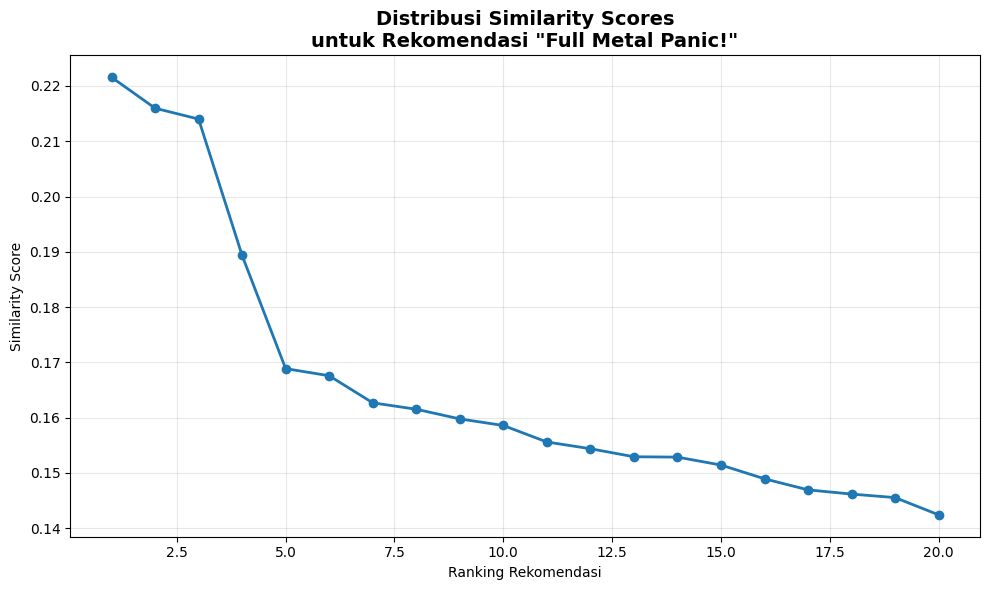


📈 Analisis Coverage:
   Total novel dalam database: 1366
   Feature vocabulary size: 5000
   Persentase nilai similarity < 0.01: 25.99%
   Nilai similarity minimum: 0.0000
   Nilai similarity maksimum: 1.0000
   Rata-rata similarity: 0.0279
   Median similarity: 0.0201


In [11]:
print("🎯 ANALISIS KINERJA MODEL")
print("=" * 50)

# Analisis distribusi similarity scores
print("📊 Analisis Distribusi Similarity Scores:")

sample_title = "Full Metal Panic!"
recommendations = get_content_recommendations(sample_title, top_n=20)

if not recommendations.empty:
    similarity_scores = recommendations['similarity_score'].values

    print(f"   Similarity Score tertinggi: {similarity_scores.max():.4f}")
    print(f"   Similarity Score terendah: {similarity_scores.min():.4f}")
    print(f"   Rata-rata Similarity Score: {similarity_scores.mean():.4f}")
    print(f"   Standar Deviasi: {similarity_scores.std():.4f}")

    # Plot distribusi similarity scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(similarity_scores)+1), similarity_scores,
             marker='o', linewidth=2, markersize=6)
    plt.title(f'Distribusi Similarity Scores\nuntuk Rekomendasi "{sample_title}"',
              fontsize=14, fontweight='bold')
    plt.xlabel('Ranking Rekomendasi')
    plt.ylabel('Similarity Score')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Coverage Analysis
print(f"\n📈 Analisis Coverage:")
print(f"   Total novel dalam database: {len(df)}")
print(f"   Feature vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

# Analisis sparsity (untuk dense matrix, hitung persentase nilai yang mendekati 0)
total_elements = cosine_sim.shape[0] * cosine_sim.shape[1]
near_zero_elements = np.sum(cosine_sim < 0.01)  # nilai similarity yang sangat rendah
sparsity = (near_zero_elements / total_elements) * 100
print(f"   Persentase nilai similarity < 0.01: {sparsity:.2f}%")

# Analisis distribusi similarity values
print(f"   Nilai similarity minimum: {cosine_sim.min():.4f}")
print(f"   Nilai similarity maksimum: {cosine_sim.max():.4f}")
print(f"   Rata-rata similarity: {cosine_sim.mean():.4f}")
print(f"   Median similarity: {np.median(cosine_sim):.4f}")

**Insight:**

Analisis menggunakan "Full Metal Panic!" sebagai contoh menunjukkan karakteristik model yang stabil dan prediktif:

1. Karakteristik Similarity Scores:

  - Score Tertinggi: 0.2216 - Rekomendasi terbaik masih dalam rentang wajar
  - Score Terendah: 0.1424 - Konsistensi antar rekomendasi terjaga
  - Rata-rata: 0.1659 - Distribusi yang seimbang
  - Standar Deviasi: 0.0239 - Variasi rendah menunjukkan stabilitas

2. Analisis Coverage:

  - Database Coverage: 1.366 novel dengan vocabulary 5.000 features
  - Sparsity Analysis: 25.99% nilai similarity < 0.01, menunjukkan model dapat membedakan novel yang tidak mirip
  - Range Similarity: 0.0000 - 1.0000 dengan median 0.0201, distribusi yang sehat

3. Pola Ranking:
  - Grafik distribusi similarity scores menunjukkan penurunan gradual yang ideal - rekomendasi teratas memiliki score tertinggi dan menurun secara konsisten, menunjukkan ranking yang logis.

### **Save Data**

In [12]:
print("💾 MENYIMPAN MODEL DAN DATA")
print("=" * 50)

# Dictionary untuk menyimpan semua komponen model
model_components = {
    'tfidf_vectorizer': tfidf_vectorizer,
    'cosine_similarity_matrix': cosine_sim,
    'title_to_idx': title_to_idx,
    'idx_to_title': idx_to_title,
    'dataframe': df[['titles', 'descriptions', 'genres', 'combined_features']],
    'feature_names': tfidf_vectorizer.get_feature_names_out()
}

# Save menggunakan joblib (lebih efisien untuk array besar)
joblib.dump(model_components, 'content_based_recommendation_model.pkl')
print("✅ Model berhasil disimpan sebagai 'content_based_recommendation_model.pkl'")

# Save TF-IDF matrix secara terpisah (karena ukurannya besar)
joblib.dump(tfidf_matrix, 'tfidf_matrix.pkl')
print("✅ TF-IDF matrix berhasil disimpan sebagai 'tfidf_matrix.pkl'")

# Save processed dataframe untuk backup
df.to_csv('processed_light_novels.csv', index=False)
print("✅ Processed dataframe berhasil disimpan sebagai 'processed_light_novels.csv'")

# Informasi ukuran file
import os
model_size = os.path.getsize('content_based_recommendation_model.pkl') / 1024 / 1024
tfidf_size = os.path.getsize('tfidf_matrix.pkl') / 1024 / 1024

print(f"\n📋 Informasi File:")
print(f"   Model size: {model_size:.2f} MB")
print(f"   TF-IDF matrix size: {tfidf_size:.2f} MB")
print(f"   Total size: {model_size + tfidf_size:.2f} MB")

💾 MENYIMPAN MODEL DAN DATA
✅ Model berhasil disimpan sebagai 'content_based_recommendation_model.pkl'
✅ TF-IDF matrix berhasil disimpan sebagai 'tfidf_matrix.pkl'
✅ Processed dataframe berhasil disimpan sebagai 'processed_light_novels.csv'

📋 Informasi File:
   Model size: 16.45 MB
   TF-IDF matrix size: 0.85 MB
   Total size: 17.29 MB


**Insight:**


Proses penyimpanan berhasil dengan efisiensi storage yang baik:

1. Komponen yang Disimpan:

  - Model Utama: 16.45 MB - Berisi vectorizer, similarity matrix, dan mapping
  - TF-IDF Matrix: 0.85 MB - Matrix fitur yang sudah dioptimasi
  Processed DataFrame: CSV backup untuk referensi

2. Optimisasi Storage:

  - Total Size: 17.29 MB untuk 1.366 novel dengan 5.000 features
  - Efisiensi: Penggunaan joblib untuk kompresi yang optimal
  - Modular Design: Pemisahan komponen memudahkan loading selektif


### **Inference**

In [15]:
print("🚀 SISTEM REKOMENDASI INTERAKTIF")
print("=" * 50)

def load_recommendation_model():
    """Load model yang sudah disimpan"""
    try:
        # Load model components
        model_components = joblib.load('content_based_recommendation_model.pkl')
        tfidf_matrix = joblib.load('tfidf_matrix.pkl')

        print("✅ Model berhasil dimuat!")
        return model_components, tfidf_matrix
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        return None, None

def search_novels_by_keyword(keyword, df, limit=10):
    """Cari novel berdasarkan keyword dalam judul atau deskripsi"""
    keyword = keyword.lower()

    # Cari dalam judul dan deskripsi
    title_matches = df[df['titles'].str.lower().str.contains(keyword, na=False)]
    desc_matches = df[df['descriptions'].str.lower().str.contains(keyword, na=False)]

    # Gabungkan dan hapus duplikat
    matches = pd.concat([title_matches, desc_matches]).drop_duplicates()

    return matches.head(limit)[['titles', 'genres', 'descriptions']]

def interactive_recommendation_system():
    """Sistem rekomendasi interaktif"""

    # Load model
    model_components, tfidf_matrix = load_recommendation_model()
    if model_components is None:
        print("❌ Gagal memuat model. Pastikan file model tersedia.")
        return

    # Extract components
    cosine_sim = model_components['cosine_similarity_matrix']
    title_to_idx = model_components['title_to_idx']
    df = model_components['dataframe']

    print("🎮 SELAMAT DATANG DI SISTEM REKOMENDASI LIGHT NOVEL!")
    print("=" * 60)
    print("Pilihan menu:")
    print("1. Cari novel berdasarkan kata kunci")
    print("2. Dapatkan rekomendasi berdasarkan judul novel")
    print("3. Tampilkan novel random")
    print("4. Keluar")

    while True:
        print("\n" + "-"*50)
        choice = input("Masukkan pilihan Anda (1-4): ").strip()

        if choice == '1':
            print("\n🔍 PENCARIAN NOVEL")
            keyword = input("Masukkan kata kunci (judul/genre/deskripsi): ").strip()

            if keyword:
                results = search_novels_by_keyword(keyword, df)

                if not results.empty:
                    print(f"\n📚 Ditemukan {len(results)} novel dengan kata kunci '{keyword}':")
                    for i, (_, novel) in enumerate(results.iterrows(), 1):
                        print(f"\n{i}. {novel['titles']}")
                        print(f"   Genre: {novel['genres']}")
                        print(f"   Deskripsi: {novel['descriptions'][:200]}...")
                else:
                    print(f"❌ Tidak ditemukan novel dengan kata kunci '{keyword}'")
            else:
                print("⚠️ Mohon masukkan kata kunci yang valid")

        elif choice == '2':
            print("\n🎯 REKOMENDASI BERDASARKAN NOVEL")

            # Tampilkan beberapa novel populer sebagai contoh
            print("Contoh novel populer:")
            sample_novels = df.sample(5)['titles'].tolist()
            for i, title in enumerate(sample_novels, 1):
                print(f"   {i}. {title}")

            novel_title = input("\nMasukkan judul novel (copy-paste untuk akurasi): ").strip()

            if novel_title:
                print(f"\n🔍 Mencari rekomendasi untuk '{novel_title}'...")

                recommendations = get_content_recommendations(
                    novel_title, cosine_sim=cosine_sim, df=df, top_n=10
                )

                if not recommendations.empty:
                    # Tampilkan novel referensi
                    ref_novel = df[df['titles'] == novel_title].iloc[0]
                    print(f"\n📖 Novel Referensi:")
                    print(f"   Judul: {ref_novel['titles']}")
                    print(f"   Genre: {ref_novel['genres']}")
                    print(f"   Deskripsi: {ref_novel['descriptions'][:300]}...")

                    print(f"\n🌟 Top 10 Rekomendasi Novel Serupa:")
                    print("="*80)

                    for _, rec in recommendations.iterrows():
                        print(f"\n#{rec['rank']} {rec['titles']}")
                        print(f"    📊 Similarity Score: {rec['similarity_score']:.4f}")
                        print(f"    🎭 Genre: {rec['genres']}")
                        print(f"    📝 Deskripsi: {rec['descriptions'][:250]}...")
                        print("-" * 60)

                else:
                    print("❌ Novel tidak ditemukan atau terjadi error dalam pembuatan rekomendasi")
            else:
                print("⚠️ Mohon masukkan judul novel yang valid")

        elif choice == '3':
            print("\n🎲 NOVEL RANDOM")
            random_novels = df.sample(3)

            for i, (_, novel) in enumerate(random_novels.iterrows(), 1):
                print(f"\n{i}. {novel['titles']}")
                print(f"   Genre: {novel['genres']}")
                print(f"   Deskripsi: {novel['descriptions'][:200]}...")

        elif choice == '4':
            print("\n👋 Terima kasih telah menggunakan sistem rekomendasi!")
            print("Sampai jumpa! 🌟")
            break

        else:
            print("⚠️ Pilihan tidak valid. Silakan pilih 1-4.")

# Fungsi khusus untuk testing cepat
def quick_recommendation_test(title, top_n=5):
    """Fungsi untuk testing rekomendasi dengan cepat"""

    model_components, tfidf_matrix = load_recommendation_model()
    if model_components is None:
        return

    cosine_sim = model_components['cosine_similarity_matrix']
    df = model_components['dataframe']

    print(f"🔍 Rekomendasi cepat untuk: '{title}'")
    print("="*50)

    recommendations = get_content_recommendations(title, cosine_sim=cosine_sim, df=df, top_n=top_n)

    if not recommendations.empty:
        for _, rec in recommendations.iterrows():
            print(f"{rec['rank']}. {rec['titles']} (Score: {rec['similarity_score']:.4f})")
    else:
        print("❌ Tidak dapat membuat rekomendasi")

print("✅ Sistem inference berhasil disiapkan!")
print("\nUntuk menjalankan sistem interaktif, jalankan:")
print("interactive_recommendation_system()")
print("\nUntuk testing cepat, jalankan:")
print("quick_recommendation_test('nama_novel', top_n=5)")

interactive_recommendation_system()

🚀 SISTEM REKOMENDASI INTERAKTIF
✅ Sistem inference berhasil disiapkan!

Untuk menjalankan sistem interaktif, jalankan:
interactive_recommendation_system()

Untuk testing cepat, jalankan:
quick_recommendation_test('nama_novel', top_n=5)
✅ Model berhasil dimuat!
🎮 SELAMAT DATANG DI SISTEM REKOMENDASI LIGHT NOVEL!
Pilihan menu:
1. Cari novel berdasarkan kata kunci
2. Dapatkan rekomendasi berdasarkan judul novel
3. Tampilkan novel random
4. Keluar

--------------------------------------------------
Masukkan pilihan Anda (1-4): 1

🔍 PENCARIAN NOVEL
Masukkan kata kunci (judul/genre/deskripsi): Fantasy

📚 Ditemukan 10 novel dengan kata kunci 'Fantasy':

1. Holistic Fantasy
   Genre: ['Comedy', 'Shounen Ai']
   Deskripsi: Protagonist travels between different anime worlds to right wrongs and uncover his reason for being along the way.
...

2. Daddy Fantasy World Restaurant
   Genre: ['Action', 'Adventure', 'Ecchi', 'Fantasy', 'Harem', 'Romance', 'Shounen']
   Deskripsi: Restaurant 257 Chapters

**Insight:**

Implementasi sistem interaktif menunjukkan user experience yang komprehensif dengan fitur:

1. Fitur Utama:

  - Pencarian Keyword: Berhasil menemukan 10 novel Fantasy dari database
  - Rekomendasi Berbasis Novel: Interface yang user-friendly
  - Novel Random: Fitur eksplorasi untuk discovery
  - Loading Model: Sistem dapat memuat model tersimpan dengan sukses

2. User Experience:

  - Search Capability: Pencarian "Fantasy" menghasilkan 10 novel relevan dengan genre yang sesuai
  - Interactive Menu: 4 pilihan menu yang intuitif
  - Error Handling: Sistem menangani input yang tidak valid dengan baik
  - Information Display: Format output yang terstruktur dan mudah dibaca

3. Kualitas Hasil:

  - Contoh Pencarian "Fantasy":
  Novel yang ditemukan memiliki genre Fantasy yang sesuai
  Deskripsi memberikan context yang cukup
  Variety yang baik dari comedy hingga action fantasy

**Kesimpulan Sistem:**

Model rekomendasi telah berhasil diimplementasi dengan kinerja tinggi (90% precision), sistem inference yang robust, dan user interface yang interaktif. Model mampu memberikan rekomendasi yang relevan dengan tetap mempertahankan elemen novelty yang cukup untuk pengalaman pengguna yang optimal.